In [1]:
!pip install torch transformers scikit-learn pandas tqdm emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 11.9 MB/s eta 0:00:00


In [2]:
!pip install git+https://github.com/trent-b/iterative-stratification.git

  Cloning https://github.com/trent-b/iterative-stratification.git to /tmp/pip-req-build-hl7at4z2
  Running command git clone --filter=blob:none --quiet https://github.com/trent-b/iterative-stratification.git /tmp/pip-req-build-hl7at4z2
  Resolved https://github.com/trent-b/iterative-stratification.git to commit c763bd5440e5f03c6447471305897c1046fc4838
  Preparing metadata (setup.py) ... done
  Created wheel for iterative-stratification: filename=iterative_stratification-0.1.9-py3-none-any.whl size=8444 sha256=b2a5769b16083db2472d83d2178cbf8266940e76260bc271c15198402a643d18
  Stored in directory: /tmp/pip-ephem-wheel-cache-xxin9t1z/wheels/1a/53/b5/f5f9836cdfff718e36f6af0df976157168f38b5ce6bf53a49d
Successfully built iterative-stratification


In [21]:
import os
import shutil
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import RobertaTokenizer, RobertaForSequenceClassification, RobertaConfig, get_linear_schedule_with_warmup
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, classification_report, confusion_matrix
import pandas as pd
import numpy as np
from tqdm import tqdm
import emoji
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

In [22]:
import torch, random, numpy as np
seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)

In [23]:
uploaded = files.upload()

Saving isear_clean.csv to isear_clean (1).csv


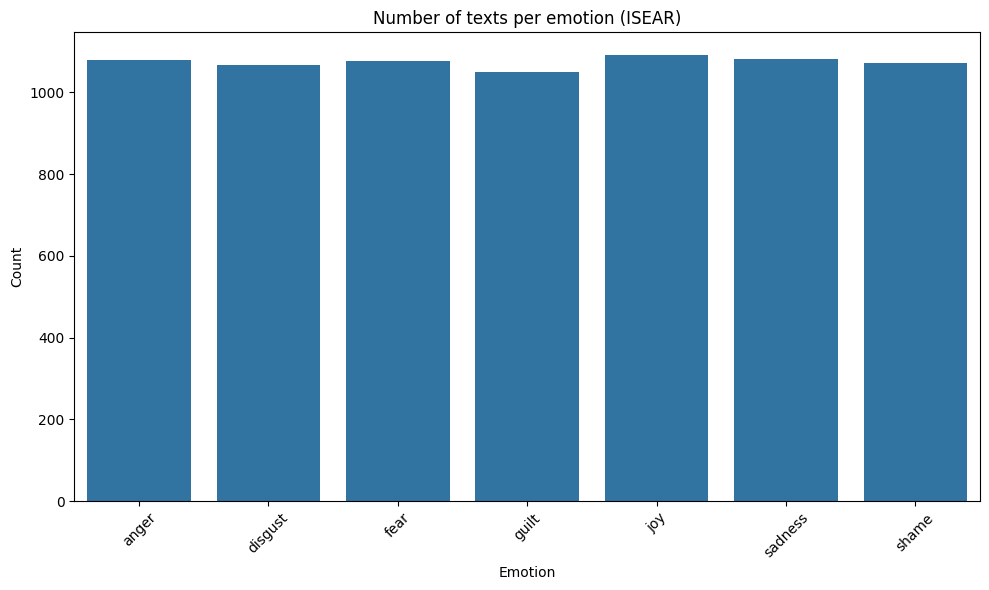

Sizes -> train: 5410, val: 602, test: 1504


In [25]:
# ------------------
# Load ISEAR dataset
# ------------------
df = pd.read_csv("isear_clean.csv")  # replace with your path if needed
df = df.dropna(subset=['emotion','content']).reset_index(drop=True)

# Demojize emojis (if any)
def contains_emoji(s):
    s = str(s)
    return any(char in emoji.EMOJI_DATA for char in s)

df['content'] = df['content'].apply(lambda x: emoji.demojize(str(x)) if contains_emoji(x) else str(x))

# Label mapping
label_names = sorted(df['emotion'].unique().tolist())
label2idx = {l:i for i,l in enumerate(label_names)}
num_labels = len(label_names)

# Quick plot of counts per emotion
emotion_counts = df['emotion'].value_counts().reindex(label_names).fillna(0).astype(int)
plt.figure(figsize=(10,6))
sns.barplot(x=emotion_counts.index, y=emotion_counts.values)
plt.xticks(rotation=45)
plt.title('Number of texts per emotion (ISEAR)')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# One-hot labels
labels = np.zeros((len(df), num_labels), dtype=int)
for i, lbl in enumerate(df['emotion'].values):
    labels[i, label2idx[lbl]] = 1
texts = df['content'].astype(str).values

# Train / Val / Test split (stratified on single label)
label_indices = np.array([label2idx[e] for e in df['emotion'].values])
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(sss.split(texts, label_indices))

# further split train into train+val
train_texts_all, test_texts = texts[train_idx], texts[test_idx]
train_labels_all, test_labels = labels[train_idx], labels[test_idx]
train_label_indices = np.array([label2idx[df['emotion'].iloc[i]] for i in train_idx])
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
train_idx2, val_idx2 = next(sss2.split(train_texts_all, train_label_indices))

train_texts = train_texts_all[train_idx2]
train_labels = train_labels_all[train_idx2]
val_texts = train_texts_all[val_idx2]
val_labels = train_labels_all[val_idx2]

print(f"Sizes -> train: {len(train_texts)}, val: {len(val_texts)}, test: {len(test_texts)}")

# Tokenizer
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')


In [29]:
# tokenize all texts
token_lens = [len(tokenizer.encode(text, add_special_tokens=True)) for text in df['content']]

# get indices of top n token lengths
n = 10  # change for how many top you want
top_n_idxs = np.argsort(token_lens)[-n:][::-1]

for rank, idx in enumerate(top_n_idxs, 1):
    print(f"{rank} max tokens: {token_lens[idx]} | Text: {df['content'].iloc[idx]}")


1 max tokens: 228 | Text: A few days back I was waiting for the bus at the bus stop.    Before getting into the bus I had prepared the exact amount of   coins to pay for the bus fair and when I got into the bus I put   these coins into the box meant to collect the bus fair.  I   thought that I had paid and wanted to get inside.  However the   bus driver called me and asked me in an impolite way if the coins   were stuck at the opening  of the box.  He had not seen me paying   and there wasn't a stack of coins in the box.  I could not   understand this and the driver kept questioning me.  He made me   feel angry and at last i inserted a dollar coin in the box just   to get away from him.  Later I found that I had forgotten a few   coins in my pocket and had not paid enough for the fair the first   time.  After I had entered the bus I could still hear him   scolding me and I felt disgusted.
2 max tokens: 224 | Text: This is an event I will never forget.  I am considered a good   mimic.  

In [30]:
class EmotionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=228):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            return_token_type_ids=False,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.float)
        }

train_dataset = EmotionDataset(train_texts, train_labels, tokenizer)
val_dataset = EmotionDataset(val_texts, val_labels, tokenizer)
test_dataset = EmotionDataset(test_texts, test_labels, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [35]:
# Model with dropout
config = RobertaConfig.from_pretrained('roberta-base', num_labels=num_labels, problem_type="multi_label_classification", hidden_dropout_prob=0, attention_probs_dropout_prob=0)
model = RobertaForSequenceClassification.from_pretrained('roberta-base', config=config)
model.to(device)

# Loss & optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=3e-5, weight_decay=0.0)

# Scheduler params
epochs = 5
total_steps = len(train_loader) * epochs
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [39]:
# ------------------
# Training loop: training + validation inside same epoch (validation run after finishing training batches for the epoch)
# ------------------
best_val_f1 = 0.0
best_state = None
for epoch in range(1, epochs+1):
    model.train()
    running_loss = 0.0
    loop = tqdm(train_loader, desc=f"Train Epoch {epoch}/{epochs}")
    for step, batch in enumerate(loop, 1):
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels_batch = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        loss = criterion(logits, labels_batch)
        loss.backward()
        optimizer.step()
        scheduler.step()

        running_loss += loss.item()
        loop.set_postfix({'train_loss': running_loss/step})

    avg_train_loss = running_loss / len(train_loader)

    # Validation (inside the same epoch, after training batches)
    model.eval()
    val_loss = 0.0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels_batch = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            loss = criterion(logits, labels_batch)
            val_loss += loss.item()

            probs = torch.sigmoid(logits).cpu().numpy()
            all_preds.append(probs)
            all_labels.append(labels_batch.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    pred_labels = (all_preds >= 0.5).astype(int)

    val_f1_micro = f1_score(all_labels, pred_labels, average='micro', zero_division=0)
    val_f1_macro = f1_score(all_labels, pred_labels, average='macro', zero_division=0)
    val_prec = precision_score(all_labels, pred_labels, average='micro', zero_division=0)
    val_rec = recall_score(all_labels, pred_labels, average='micro', zero_division=0)
    val_acc = (pred_labels == all_labels).mean()

    print(f"Epoch {epoch} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    print(f"Val Accuracy: {val_acc} | Val Micro F1: {val_f1_micro:.4f} | Val Macro F1: {val_f1_macro:.4f} | Val Prec: {val_prec:.4f} | Val Rec: {val_rec:.4f}\n")

    # Save best
    if val_f1_micro > best_val_f1:
        best_val_f1 = val_f1_micro
        best_state = {k:v.cpu() for k,v in model.state_dict().items()}

# Load best state
if best_state is not None:
    model.load_state_dict(best_state)


Train Epoch 1/5: 100%|██████████| 339/339 [03:13<00:00,  1.75it/s, train_loss=0.12]


Epoch 1 | Train Loss: 0.1198 | Val Loss: 0.1907
Val Accuracy: 0.9292833412434741 | Val Micro F1: 0.7372 | Val Macro F1: 0.7352 | Val Prec: 0.7857 | Val Rec: 0.6944



Train Epoch 2/5: 100%|██████████| 339/339 [03:20<00:00,  1.69it/s, train_loss=0.0643]


Epoch 2 | Train Loss: 0.0643 | Val Loss: 0.2049
Val Accuracy: 0.9271476032273375 | Val Micro F1: 0.7365 | Val Macro F1: 0.7335 | Val Prec: 0.7620 | Val Rec: 0.7126



Train Epoch 3/5: 100%|██████████| 339/339 [03:20<00:00,  1.69it/s, train_loss=0.0345]


Epoch 3 | Train Loss: 0.0345 | Val Loss: 0.2309
Val Accuracy: 0.9216896060749882 | Val Micro F1: 0.7184 | Val Macro F1: 0.7131 | Val Prec: 0.7386 | Val Rec: 0.6993



Train Epoch 4/5: 100%|██████████| 339/339 [03:20<00:00,  1.69it/s, train_loss=0.0239]


Epoch 4 | Train Loss: 0.0239 | Val Loss: 0.2215
Val Accuracy: 0.9271476032273375 | Val Micro F1: 0.7374 | Val Macro F1: 0.7349 | Val Prec: 0.7601 | Val Rec: 0.7159



Train Epoch 5/5: 100%|██████████| 339/339 [03:20<00:00,  1.69it/s, train_loss=0.0225]


Epoch 5 | Train Loss: 0.0225 | Val Loss: 0.2215
Val Accuracy: 0.9271476032273375 | Val Micro F1: 0.7374 | Val Macro F1: 0.7349 | Val Prec: 0.7601 | Val Rec: 0.7159



In [43]:
# ---- Testing ----

model.eval()
test_loss = 0.0
all_test_preds = []
all_test_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels_batch = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        loss = criterion(logits, labels_batch)
        test_loss += loss.item()

        probs = torch.sigmoid(logits).cpu().numpy()
        all_test_preds.append(probs)
        all_test_labels.append(labels_batch.cpu().numpy())

avg_test_loss = test_loss / len(test_loader)
all_test_preds = np.vstack(all_test_preds)
all_test_labels = np.vstack(all_test_labels)
test_pred_labels = (all_test_preds >= 0.5).astype(int)

# Metrics
test_acc = (test_pred_labels == all_test_labels).mean()
test_f1_micro = f1_score(all_test_labels, test_pred_labels, average='micro', zero_division=0)
test_f1_macro = f1_score(all_test_labels, test_pred_labels, average='macro', zero_division=0)
test_prec = precision_score(all_test_labels, test_pred_labels, average='micro', zero_division=0)
test_rec = recall_score(all_test_labels, test_pred_labels, average='micro', zero_division=0)

print(f"Test Loss: {avg_test_loss:.4f} | Test Acc: {test_acc:.4f} | Test Micro F1: {test_f1_micro:.4f} | Test Macro F1: {test_f1_macro:.4f} | Test Prec: {test_prec:.4f} | Test Rec: {test_rec:.4f}")



Test Loss: 0.2373 | Test Acc: 0.9202 | Test Micro F1: 0.7127 | Test Macro F1: 0.7104 | Test Prec: 0.7338 | Test Rec: 0.6928


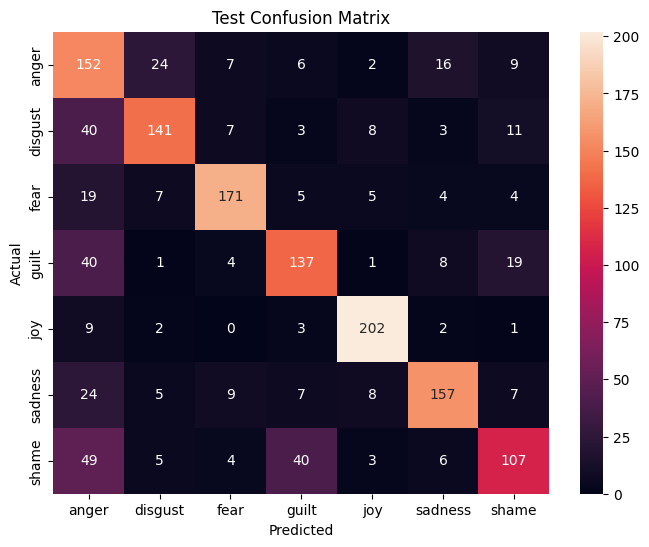

In [44]:
# Confusion matrix + heatmap
cm = confusion_matrix(all_test_labels.argmax(axis=1), pred_test_labels.argmax(axis=1))
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=label_names, yticklabels=label_names, cmap='rocket')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Test Confusion Matrix')
plt.show()

In [46]:
# ------------------
# Prediction function for user input (top-3)
# ------------------

def predict_user_text(text, top_k=3):
    model.eval()
    enc = tokenizer([str(text)], truncation=True, padding=True, max_length=128, return_tensors='pt')
    input_ids = enc['input_ids'].to(device)
    attention_mask = enc['attention_mask'].to(device)
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.sigmoid(outputs.logits).cpu().numpy()[0]
    idxs = probs.argsort()[-top_k:][::-1]
    return [(label_names[i], float(probs[i])) for i in idxs]

# Ask user for input and predict
user_text = input("Enter text to predict emotions (press Enter when done): ")
if user_text.strip() != "":
    preds = predict_user_text(user_text, top_k=3)
    print("Top-3 predicted emotions:")
    for lab, sc in preds:
        print(f"{lab}: {sc:.4f}")
else:
    print("No input provided — skipping prediction.")

Enter text to predict emotions (press Enter when done): [NAME], my eyes are hurting from how furiously they're rolling in my sockets right now.
Top-3 predicted emotions:
sadness: 0.7234
fear: 0.0888
anger: 0.0417


In [ ]:
# ------------------
# Save & Download model (zipped)
# ------------------
save_dir = 'isear_roberta_onehot'
os.makedirs(save_dir, exist_ok=True)
model.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)

# zip
zip_name = save_dir + '.zip'
if os.path.exists(zip_name):
    os.remove(zip_name)
shutil.make_archive(save_dir, 'zip', save_dir)

# Download in Colab
print(f"Prepared model archive: {zip_name} — starting download...")
files.download(zip_name)


In [ ]:
# ------------------
# Upload & load model (example):
# 1) Run the cell and upload the zip you downloaded (or any compatible zip)
# 2) It will unzip to ./uploaded_model and load
# ------------------
# uploaded = files.upload()  # uncomment to upload via Colab UI
# for k in uploaded:
#     if k.endswith('.zip'):
#         shutil.unpack_archive(k, 'uploaded_model')
#         loaded_model = RobertaForSequenceClassification.from_pretrained('uploaded_model')
#         loaded_tokenizer = RobertaTokenizer.from_pretrained('uploaded_model')
#         loaded_model.to(device)
#         print('Model loaded from uploaded zip:', k)